Exercise	9.11.	Implement	k-fold	cross-validation	from	scratch.	Compare	to	sklearn	on	
Two	Moons.	

In [2]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score

# Generate dataset
X, y = make_moons(n_samples=500,
                  noise=0.2,
                  random_state=42)

# ---------- From Scratch ----------
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

accuracies = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = KNeighborsClassifier(n_neighbors=5)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    accuracies.append(acc)

print("Scratch CV Accuracy:",
      np.mean(accuracies))

# ---------- sklearn ----------
scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X,
    y,
    cv=5
)

print("Sklearn CV Accuracy:",
      scores.mean())

Scratch CV Accuracy: 0.968
Sklearn CV Accuracy: 0.9800000000000001


Exercise	9.12.	Generate	ROC	and	PR	curves	for	logistic	regression,	decision	tree,	KNN	on	
imbalanced	data.	

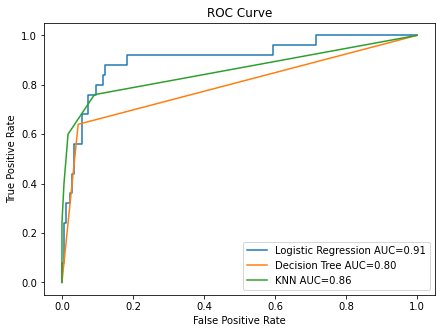

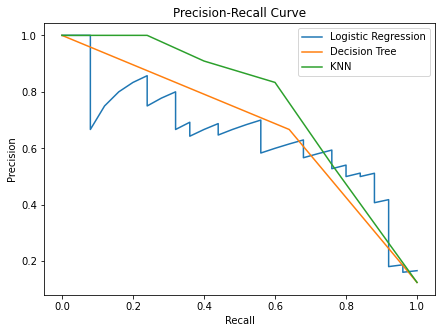

In [5]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

# Generate imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.9, 0.1],
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = \
train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "KNN":
        KNeighborsClassifier()
}

# ---------------- ROC Curve ----------------

plt.figure(figsize=(7,5))

for name, model in models.items():

    model.fit(X_train, y_train)

    # Probability scores
    probs = model.predict_proba(X_test)[:,1]

    # ROC values
    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc:.2f}"
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# ---------------- PR Curve ----------------

plt.figure(figsize=(7,5))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = \
    precision_recall_curve(
        y_test,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

Exercise	9.13.	Implement	grid	search	and	random	search	for	decision	tree	
hyperparameters.	Compare.

In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

# Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = \
train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Parameter grid
params = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Model
model = DecisionTreeClassifier()

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Score:
0.9049999999999999


Exercise	9.14.	Generate	learning	curves	for	unlimited	vs	limited	depth	trees.	Diagnose	
bias/variance.

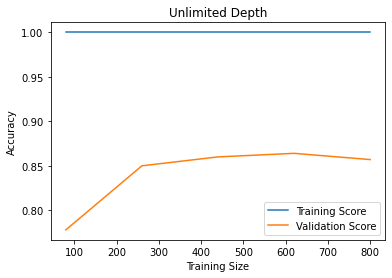

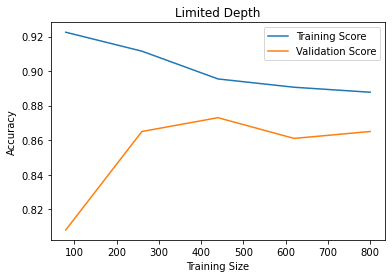

In [7]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)

# Models
models = {
    "Unlimited Depth":
        DecisionTreeClassifier(
            max_depth=None
        ),

    "Limited Depth":
        DecisionTreeClassifier(
            max_depth=3
        )
}

# Plot learning curves
for name, model in models.items():

    train_sizes, train_scores, \
    test_scores = learning_curve(
        model,
        X,
        y,
        cv=5
    )

    # Average scores
    train_mean = train_scores.mean(axis=1)

    test_mean = test_scores.mean(axis=1)

    # Plot
    plt.plot(
        train_sizes,
        train_mean,
        label="Training Score"
    )

    plt.plot(
        train_sizes,
        test_mean,
        label="Validation Score"
    )

    plt.title(name)

    plt.xlabel("Training Size")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

Exercise	9.15.	Implement	McNemar's	test	to	compare	logistic	regression	vs	neural	
network	on	Two	Moons.

In [9]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from statsmodels.stats.contingency_tables \
import mcnemar

# Generate dataset
X, y = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = \
train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Models
lr = LogisticRegression()

nn = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

# Train models
lr.fit(X_train, y_train)

nn.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)

pred_nn = nn.predict(X_test)

# McNemar contingency values
b = 0
c = 0

for i in range(len(y_test)):

    lr_correct = \
    pred_lr[i] == y_test[i]

    nn_correct = \
    pred_nn[i] == y_test[i]

    # LR correct, NN wrong
    if lr_correct and not nn_correct:
        b += 1

    # NN correct, LR wrong
    elif not lr_correct and nn_correct:
        c += 1

# Contingency table
table = [
    [0, b],
    [c, 0]
]

# McNemar test
result = mcnemar(
    table,
    exact=True
)

print("Statistic:",
      result.statistic)

print("p-value:",
      result.pvalue)

Statistic: 0.0
p-value: 1.0
